In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import missingno as msno

In [2]:
df = pd.read_csv('Cafe-Sales.zip')
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


<Axes: >

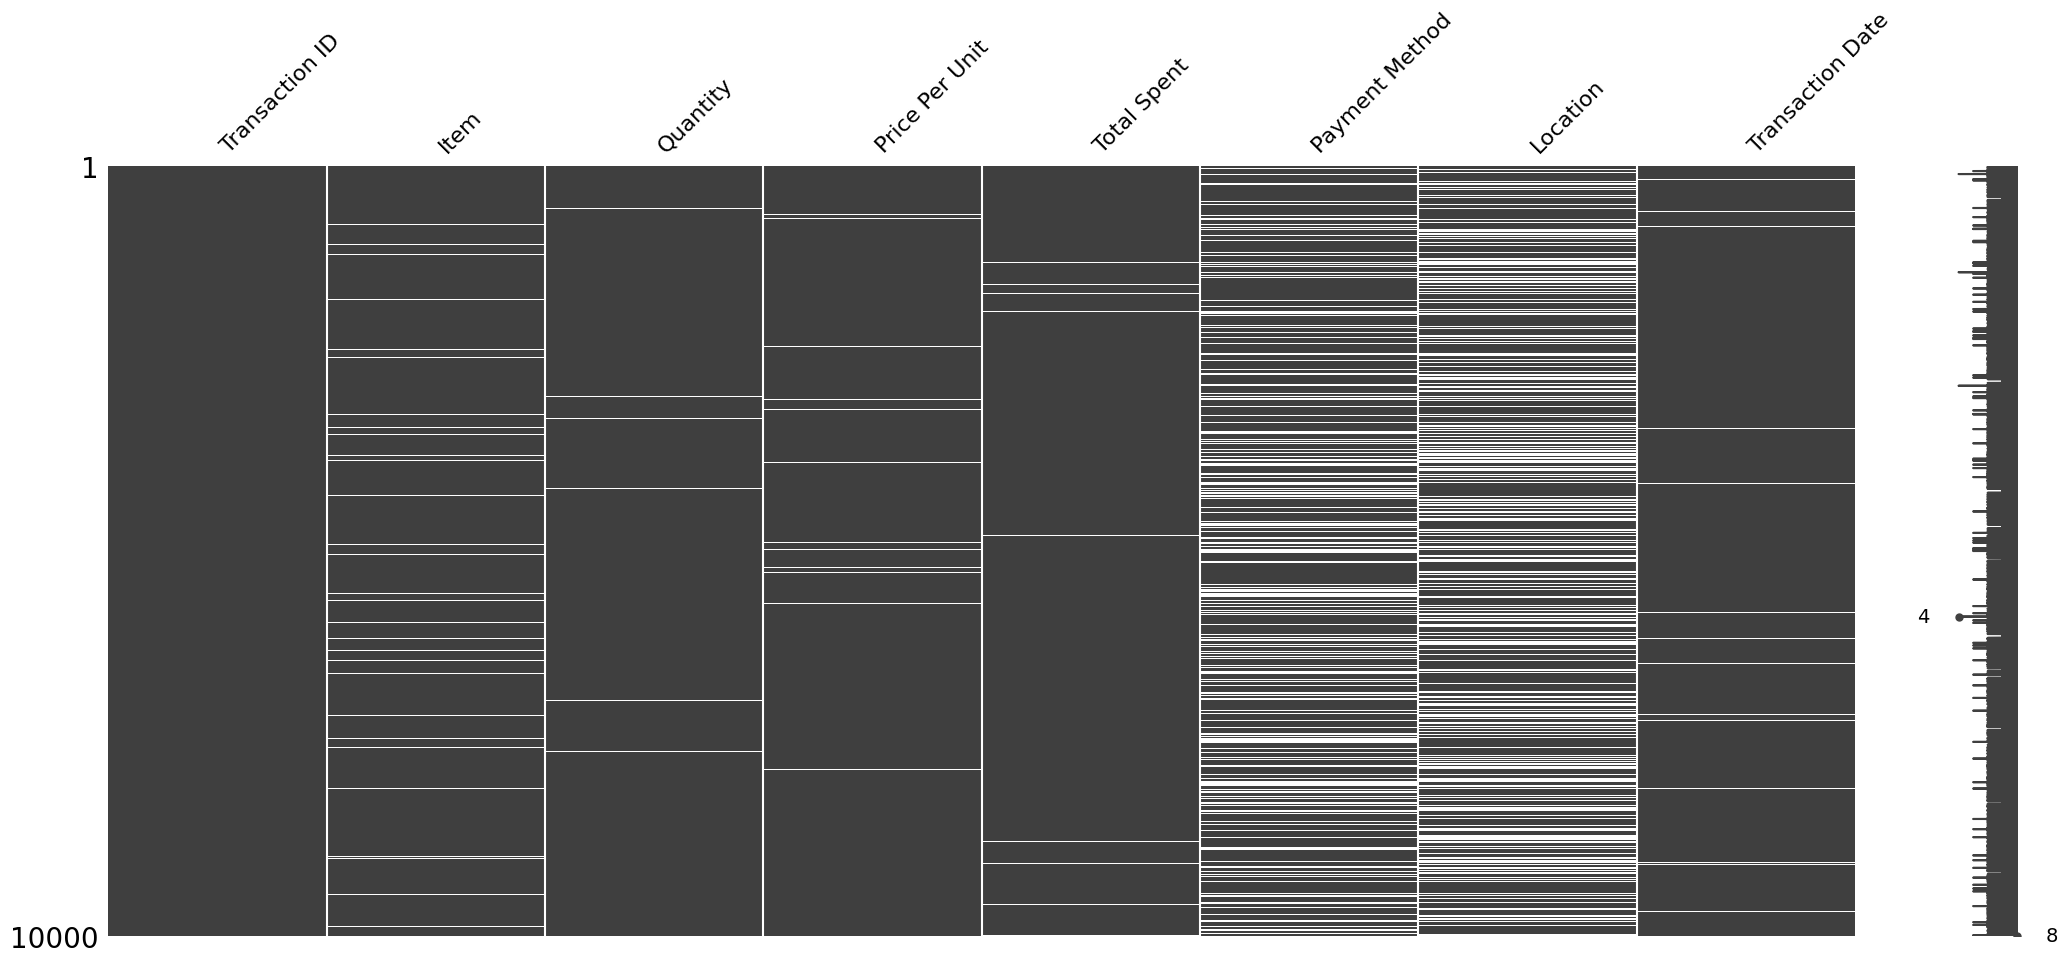

In [4]:
msno.matrix(df)

In [6]:
df.isna().sum() * 100 / len(df)

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [9]:
df.describe(include = 'object')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [10]:
df['Price Per Unit'].sample(20)

7856        3.0
4885        3.0
733         4.0
4111        4.0
3521        5.0
518         4.0
6118        1.5
5762        2.0
1602        3.0
1484        5.0
5039        NaN
2396    UNKNOWN
2598        1.5
3743        1.0
9257        2.0
3777        3.0
3694        1.5
5398        4.0
8752        5.0
3693        5.0
Name: Price Per Unit, dtype: object

In [14]:
df['Price Per Unit'].value_counts()

Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64

In [24]:
df['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

In [23]:
missing_values_price_per_unit = df.groupby('Price Per Unit')['Item'].apply(lambda x: x.isna().sum()) 
missing_values_price_per_unit

Price Per Unit
1.0        38
1.5        33
2.0        39
3.0        80
4.0        82
5.0        38
ERROR       8
UNKNOWN     8
Name: Item, dtype: int64

In [5]:
df_copy = df.copy()
df_copy.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [6]:
df_copy.dropna(subset = ['Item', 'Price Per Unit'], inplace = True)

In [5]:
df_copy.isna().sum() * 100 / len(df)

Transaction ID       0.00
Item                 0.00
Quantity             1.34
Price Per Unit       0.00
Total Spent          1.67
Payment Method      24.43
Location            31.07
Transaction Date     1.44
dtype: float64

In [32]:
df_copy['Transaction Date'].value_counts()

Transaction Date
UNKNOWN       152
ERROR         132
2023-07-24     38
2023-07-21     38
2023-03-13     38
             ... 
2023-02-17     14
2023-11-24     14
2023-04-22     14
2023-04-27     13
2023-03-11     13
Name: count, Length: 367, dtype: int64

In [7]:
df_copy.dropna(subset = ['Transaction Date', 'Total Spent'], inplace = True)

In [34]:
df_copy.isna().sum()

Transaction ID         0
Item                   0
Quantity             131
Price Per Unit         0
Total Spent            0
Payment Method      2354
Location            2999
Transaction Date       0
dtype: int64

In [8]:
df_copy.dropna(subset = ['Quantity'], inplace = True)

In [8]:
df_copy.isna().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2322
Location            2959
Transaction Date       0
dtype: int64

In [37]:
df_copy['Payment Method'].value_counts()

Payment Method
Digital Wallet    2085
Cash              2049
Credit Card       2048
ERROR              289
UNKNOWN            266
Name: count, dtype: int64

In [45]:
df_copy['Payment Method'].mode()

0    Digital Wallet
Name: Payment Method, dtype: object

In [9]:
df_copy['Payment Method'] = df_copy['Payment Method'].fillna(df_copy['Payment Method'].mode()[0])

In [15]:
df_copy.isna().sum() * 100 / len (df_copy)

Transaction ID       0.00
Item                 0.00
Quantity             0.00
Price Per Unit       0.00
Total Spent          0.00
Payment Method       0.00
Location            29.59
Transaction Date     0.00
dtype: float64

In [19]:
df_copy['Location'].value_counts()

Location
Takeaway    2740
In-store    2728
ERROR        327
UNKNOWN      305
Name: count, dtype: int64

In [31]:
df_copy[['Location']].sample(30)

,Location
3718,In-store
3661,NaN
9868,Takeaway
8666,Takeaway
2933,Takeaway
9405,In-store
3887,In-store
9977,In-store
3270,In-store
8432,Takeaway


In [35]:
missing_values_Location = df_copy.groupby('Payment Method')['Location'].apply(lambda x: x.isna().sum())
missing_values_Location

Payment Method
Cash               657
Credit Card        679
Digital Wallet    1414
ERROR              110
UNKNOWN             99
Name: Location, dtype: int64

In [29]:
unknown_Location = df_copy[df_copy['Location'] == 'UNKNOWN']
unknown_Location

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
35,TXN_9130559,Sandwich,1,4.0,4.0,Credit Card,UNKNOWN,2023-05-28
106,TXN_3775339,Cookie,3,1.0,3.0,Credit Card,UNKNOWN,2023-04-03
117,TXN_2148617,Juice,ERROR,3.0,9.0,Digital Wallet,UNKNOWN,2023-01-10
...,...,...,...,...,...,...,...,...
9908,TXN_8922585,Salad,5,5.0,25.0,Credit Card,UNKNOWN,2023-06-22
9910,TXN_2338617,ERROR,2,3.0,6.0,Digital Wallet,UNKNOWN,2023-01-12
9913,TXN_8408353,Tea,1,1.5,1.5,Credit Card,UNKNOWN,2023-12-13
9985,TXN_3297457,Cake,2,3.0,6.0,Digital Wallet,UNKNOWN,2023-01-03


In [36]:
error_Location = df_copy[df_copy['Location'] == 'ERROR']
error_Location

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
18,TXN_8876618,Cake,5,3.0,15.0,Cash,ERROR,2023-03-25
31,TXN_8927252,UNKNOWN,2,1.0,ERROR,Credit Card,ERROR,2023-11-06
49,TXN_8230936,Cake,3,3.0,9.0,Digital Wallet,ERROR,2023-05-02
73,TXN_4238417,Salad,2,5.0,10.0,Digital Wallet,ERROR,2023-06-19
74,TXN_1900620,Smoothie,2,4.0,8.0,Credit Card,ERROR,2023-12-14
...,...,...,...,...,...,...,...,...
9635,TXN_5751040,Tea,5,1.5,7.5,Cash,ERROR,2023-02-27
9692,TXN_4663529,Sandwich,5,4.0,20.0,Digital Wallet,ERROR,2023-12-24
9877,TXN_1964893,Smoothie,1,4.0,4.0,Digital Wallet,ERROR,ERROR
9889,TXN_3534588,Salad,1,5.0,5.0,Cash,ERROR,2023-07-05


In [10]:
df_copy['Location'].replace('ERROR', np.nan,  inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\372641824.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Location'].replace('ERROR', np.nan,  inplace = True)


In [50]:
df_copy.isna().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method         0
Location            2959
Transaction Date       0
dtype: int64

In [53]:
df_copy[['Location']].sample(20)

,Location
9219,In-store
6994,In-store
4882,In-store
945,Takeaway
9609,NaN
8102,Takeaway
2748,UNKNOWN
582,Takeaway
9356,Takeaway
9641,NaN


In [11]:
df_copy['Location'].replace('UNKNOWN', np.nan, inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\3480099848.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Location'].replace('UNKNOWN', np.nan, inplace = True)


In [55]:
df_copy['Location'].sample(20)

9655         NaN
8474         NaN
5035    Takeaway
7723         NaN
8478    Takeaway
2235    In-store
2239         NaN
6913         NaN
1971         NaN
7997    Takeaway
7902         NaN
7958    In-store
8218         NaN
279          NaN
2851         NaN
8531    In-store
1309    In-store
8920    In-store
3688    Takeaway
6566    In-store
Name: Location, dtype: object

In [57]:
df_copy.isna().sum() * 100 / len(df_copy)

Transaction ID       0.000000
Item                 0.000000
Quantity             0.000000
Price Per Unit       0.000000
Total Spent          0.000000
Payment Method       0.000000
Location            39.640137
Transaction Date     0.000000
dtype: float64

In [58]:
df_copy['Location'].mode()

0    Takeaway
Name: Location, dtype: object

In [59]:
df_copy['Location'].value_counts()

Location
Takeaway    2740
In-store    2728
Name: count, dtype: int64

In [12]:
df_copy['Location'] = df_copy['Location'].fillna('UNKNOWN')

In [64]:
df_copy.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [65]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    9059 non-null   object
 1   Item              9059 non-null   object
 2   Quantity          9059 non-null   object
 3   Price Per Unit    9059 non-null   object
 4   Total Spent       9059 non-null   object
 5   Payment Method    9059 non-null   object
 6   Location          9059 non-null   object
 7   Transaction Date  9059 non-null   object
dtypes: object(8)
memory usage: 637.0+ KB


In [69]:
df_copy[['Quantity']].sample(20)

,Quantity
3566,5
2126,ERROR
4253,2
5519,2
7487,NaN
7671,5
424,5
3952,4
2418,4
8390,4


In [13]:
df_copy['Quantity'].replace('UNKNOWN', np.nan, inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\1607793177.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Quantity'].replace('UNKNOWN', np.nan, inplace = True)


In [14]:
df_copy['Quantity'].replace('ERROR', np.nan, inplace = True)


C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\2075424843.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Quantity'].replace('ERROR', np.nan, inplace = True)


In [72]:
df_copy.isna().sum() * 100 / len(df_copy)

Transaction ID      0.000000
Item                0.000000
Quantity            3.444089
Price Per Unit      0.000000
Total Spent         0.000000
Payment Method      0.000000
Location            0.000000
Transaction Date    0.000000
dtype: float64

In [15]:
df_copy['Quantity'].fillna(method = 'ffill', inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\717330317.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Quantity'].fillna(method = 'ffill', inplace = True)
C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\717330317.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy['Quantity'].fillna(method = 'ffill', inplace = True)


In [74]:
df_copy.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [75]:
df_copy.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    9059 non-null   object
 1   Item              9059 non-null   object
 2   Quantity          9059 non-null   object
 3   Price Per Unit    9059 non-null   object
 4   Total Spent       9059 non-null   object
 5   Payment Method    9059 non-null   object
 6   Location          9059 non-null   object
 7   Transaction Date  9059 non-null   object
dtypes: object(8)
memory usage: 637.0+ KB


In [16]:
df_copy['Quantity'] = pd.to_numeric(df['Quantity'], errors = 'coerce')

In [82]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9059 non-null   object 
 1   Item              9059 non-null   object 
 2   Quantity          9059 non-null   float64
 3   Price Per Unit    9059 non-null   object 
 4   Total Spent       9059 non-null   object 
 5   Payment Method    9059 non-null   object 
 6   Location          9059 non-null   object 
 7   Transaction Date  9059 non-null   object 
dtypes: float64(1), object(7)
memory usage: 637.0+ KB


In [81]:
df_copy.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [17]:
df_copy['Price Per Unit'] = pd.to_numeric(df_copy['Price Per Unit'], errors = 'coerce')

In [84]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9059 non-null   object 
 1   Item              9059 non-null   object 
 2   Quantity          9059 non-null   float64
 3   Price Per Unit    8733 non-null   float64
 4   Total Spent       9059 non-null   object 
 5   Payment Method    9059 non-null   object 
 6   Location          9059 non-null   object 
 7   Transaction Date  9059 non-null   object 
dtypes: float64(2), object(6)
memory usage: 637.0+ KB


In [86]:
df_copy.isna().sum() * 100 /len(df_copy)

Transaction ID      0.000000
Item                0.000000
Quantity            0.000000
Price Per Unit      3.598631
Total Spent         0.000000
Payment Method      0.000000
Location            0.000000
Transaction Date    0.000000
dtype: float64

In [18]:
df_copy['Price Per Unit'].fillna(method = 'bfill', inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\2962631409.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Price Per Unit'].fillna(method = 'bfill', inplace = True)
C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\2962631409.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy['Price Per Unit'].fillna(method = 'bfill', inplace = True)


In [88]:
df_copy.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [89]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9059 non-null   object 
 1   Item              9059 non-null   object 
 2   Quantity          9059 non-null   float64
 3   Price Per Unit    9059 non-null   float64
 4   Total Spent       9059 non-null   object 
 5   Payment Method    9059 non-null   object 
 6   Location          9059 non-null   object 
 7   Transaction Date  9059 non-null   object 
dtypes: float64(2), object(6)
memory usage: 637.0+ KB


In [91]:
df_copy[['Price Per Unit']].sample(20)

,Price Per Unit
2544,4.0
1583,3.0
8608,4.0
5132,4.0
3783,4.0
6083,1.0
515,4.0
6188,1.5
22,4.0
8055,4.0


In [19]:
df_copy['Total Spent'] = pd.to_numeric(df['Total Spent'], errors = 'coerce')

In [96]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9059 non-null   object 
 1   Item              9059 non-null   object 
 2   Quantity          9059 non-null   float64
 3   Price Per Unit    9059 non-null   float64
 4   Total Spent       8748 non-null   float64
 5   Payment Method    9059 non-null   object 
 6   Location          9059 non-null   object 
 7   Transaction Date  9059 non-null   object 
dtypes: float64(3), object(5)
memory usage: 637.0+ KB


In [98]:
df_copy.isna().sum() * 100 / len(df_copy)

Transaction ID      0.00000
Item                0.00000
Quantity            0.00000
Price Per Unit      0.00000
Total Spent         3.43305
Payment Method      0.00000
Location            0.00000
Transaction Date    0.00000
dtype: float64

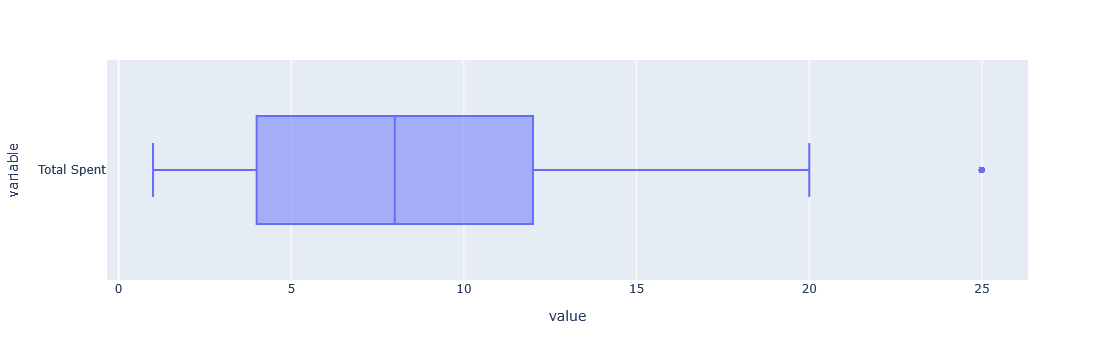

In [99]:
px.box(df_copy, ['Total Spent'])

In [101]:
df_copy.describe()

,Quantity,Price Per Unit,Total Spent
count,9059.000000,9059.000000,8748.000000
mean,3.025720,2.952975,8.919353
std,1.419629,1.277209,6.020200
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [20]:
df_copy['Total Spent'].fillna(df_copy['Total Spent'].median(), inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_17620\3381295466.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Total Spent'].fillna(df_copy['Total Spent'].median(), inplace = True)


In [104]:
df_copy.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [105]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9059 non-null   object 
 1   Item              9059 non-null   object 
 2   Quantity          9059 non-null   float64
 3   Price Per Unit    9059 non-null   float64
 4   Total Spent       9059 non-null   float64
 5   Payment Method    9059 non-null   object 
 6   Location          9059 non-null   object 
 7   Transaction Date  9059 non-null   object 
dtypes: float64(3), object(5)
memory usage: 637.0+ KB


In [21]:
df_copy['Transaction Date'] = pd.to_datetime(df_copy['Transaction Date'], errors = 'coerce')

In [107]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9059 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9059 non-null   object        
 1   Item              9059 non-null   object        
 2   Quantity          9059 non-null   float64       
 3   Price Per Unit    9059 non-null   float64       
 4   Total Spent       9059 non-null   float64       
 5   Payment Method    9059 non-null   object        
 6   Location          9059 non-null   object        
 7   Transaction Date  8788 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 637.0+ KB


In [109]:
df_copy.isna().sum() * 100 / len(df_copy)

Transaction ID      0.0000
Item                0.0000
Quantity            0.0000
Price Per Unit      0.0000
Total Spent         0.0000
Payment Method      0.0000
Location            0.0000
Transaction Date    2.9915
dtype: float64

In [22]:
df_copy.dropna(subset = ['Transaction Date'], inplace = True)

In [111]:
df_copy.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [112]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8788 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    8788 non-null   object        
 1   Item              8788 non-null   object        
 2   Quantity          8788 non-null   float64       
 3   Price Per Unit    8788 non-null   float64       
 4   Total Spent       8788 non-null   float64       
 5   Payment Method    8788 non-null   object        
 6   Location          8788 non-null   object        
 7   Transaction Date  8788 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 617.9+ KB


<Axes: >

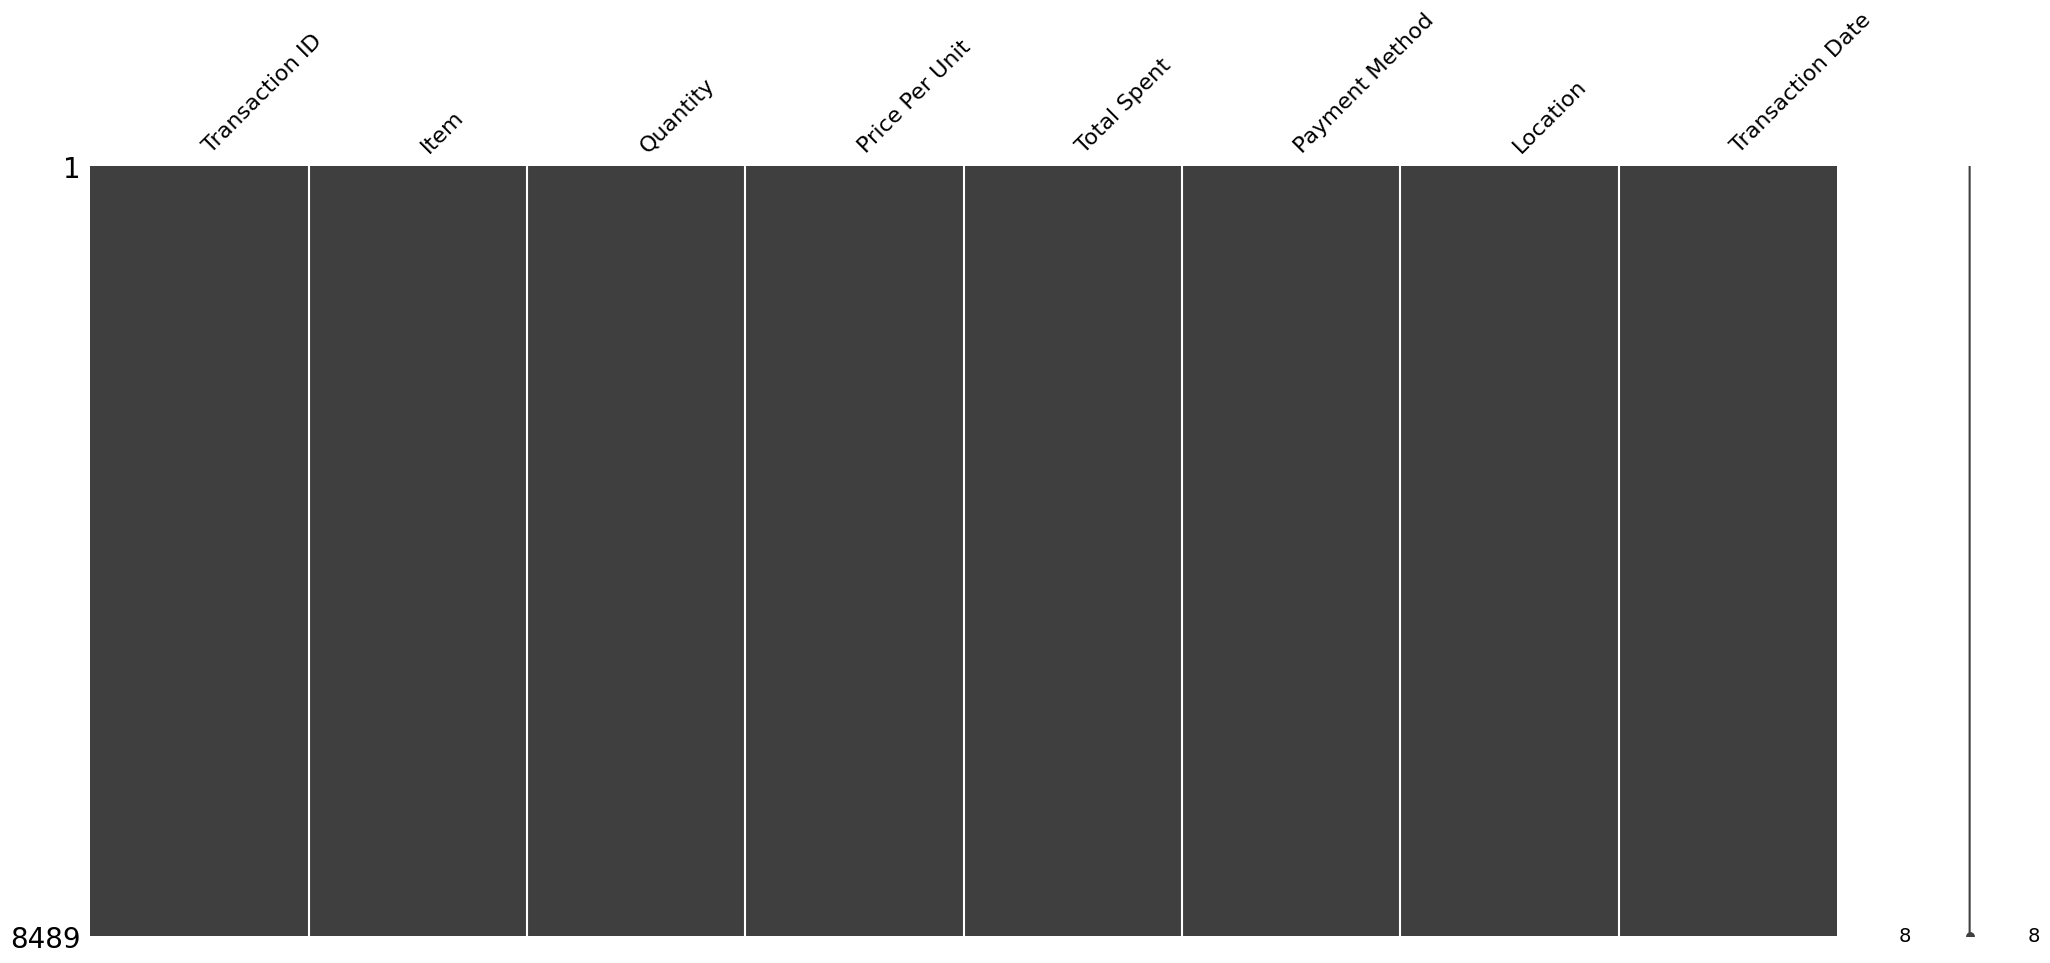

In [25]:
msno.matrix(df_copy)

In [24]:
df_copy.dropna(subset = ['Quantity'], inplace = True)

In [24]:
df_copy.isna().sum() * 100 / len(df_copy)

Transaction ID       0.000000
Item                 0.000000
Quantity             3.402367
Price Per Unit       0.000000
Total Spent          0.000000
Payment Method       0.000000
Location            39.724624
Transaction Date     0.000000
dtype: float64

In [30]:
df_copy[['Location']].sample(20)

,Location
7795,NaN
8971,NaN
555,NaN
3949,In-store
4470,NaN
4473,NaN
1985,Takeaway
7729,NaN
4020,Takeaway
2519,Takeaway


In [32]:
df_copy['Location'].fillna(method = 'ffill', inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_18816\3295104414.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Location'].fillna(method = 'ffill', inplace = True)
C:\Users\AsUs\AppData\Local\Temp\ipykernel_18816\3295104414.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy['Location'].fillna(method = 'ffill', inplace = True)


In [121]:
df_copy.duplicated().sum() 

np.int64(0)

In [122]:
df_copy.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,8788.000000,8788.000000,8788.000000,8788
mean,3.022303,2.953402,8.878471,2023-07-01 18:04:15.621301760
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.418778,1.277310,5.916313,NaN


In [124]:
df_copy.describe(include = 'object')

,Transaction ID,Item,Payment Method,Location
count,8788,8788,8788,8788
unique,8788,10,5,3
top,TXN_1961373,Juice,Digital Wallet,UNKNOWN
freq,1,1085,4266,3491


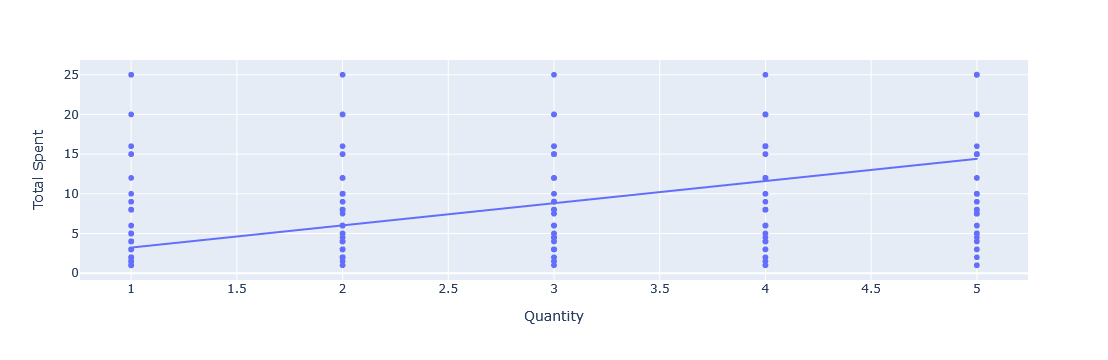

In [132]:
px.scatter(df_copy, x = 'Quantity', y = 'Total Spent', trendline = 'ols')

In [133]:
df_copy[['Quantity', 'Total Spent']].corr()

,Quantity,Total Spent
Quantity,1.000000,0.670255
Total Spent,0.670255,1.000000


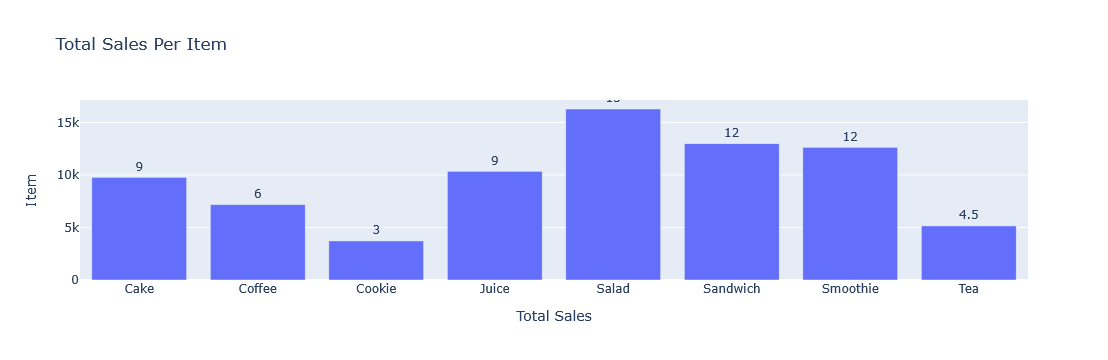

In [153]:
bar_chart = px.bar(df_copy.groupby('Item')['Total Spent'].sum().reset_index(name = 'Total_Sales'), 
                   x = 'Item', y = 'Total_Sales', title = 'Total Sales Per Item')
bar_chart.update_xaxes(title_text = 'Total Sales')
bar_chart.update_yaxes(title_text = 'Item')
bar_chart.update_traces(text = df_copy.groupby('Item')['Total Spent'].median().reset_index(name = 'Total_Sales')['Total_Sales'],
                        textposition = 'outside')
bar_chart.show()

In [143]:
df_copy[['Item']].sample(20)

,Item
8286,Salad
4258,Salad
5044,Coffee
9121,Coffee
1093,Cookie
8981,Cake
1842,Salad
6463,Cookie
5249,Smoothie
4500,Coffee


In [144]:
df_copy['Item'].replace('UNKNOWN', np.nan, inplace = True)

In [145]:
df_copy['Item'].replace('ERROR', np.nan, inplace = True)


In [147]:
df_copy.isna().sum() * 100 / len(df_copy)

Transaction ID      0.000000
Item                6.520255
Quantity            0.000000
Price Per Unit      0.000000
Total Spent         0.000000
Payment Method      0.000000
Location            0.000000
Transaction Date    0.000000
dtype: float64

In [148]:
df_copy['Item'].mode()

0    Juice
Name: Item, dtype: object

In [151]:
df_copy[['Item']].describe(include = 'object')

,Item
count,8215
unique,8
top,Juice
freq,1085


In [152]:
df_copy['Item'].fillna(method = 'ffill', inplace = True)

C:\Users\AsUs\AppData\Local\Temp\ipykernel_17872\3646124423.py:1: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [155]:
df_copy['Cost'] = df_copy['Price Per Unit'] - df_copy['Quantity']

In [27]:
df_copy.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

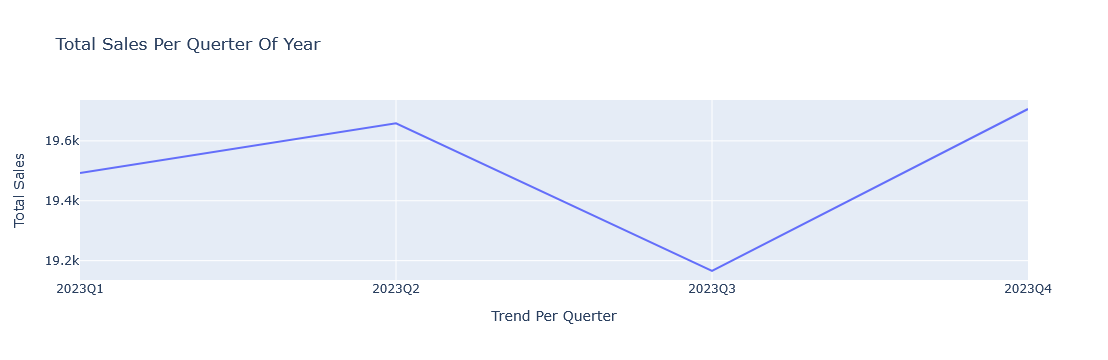

In [37]:
df_temp = df_copy.groupby(df_copy['Transaction Date'].dt.to_period('Q'))['Total Spent'].sum().reset_index(name = 'Total_Spent')
df_temp['Transaction Date'] = df_temp['Transaction Date'].astype(str)
line_chart = px.line(df_temp, x = 'Transaction Date', y = 'Total_Spent', title = 'Total Sales Per Querter Of Year')
line_chart.update_xaxes(title_text = 'Trend Per Querter')
line_chart.update_yaxes(title_text = 'Total Sales')
line_chart.show()
                     

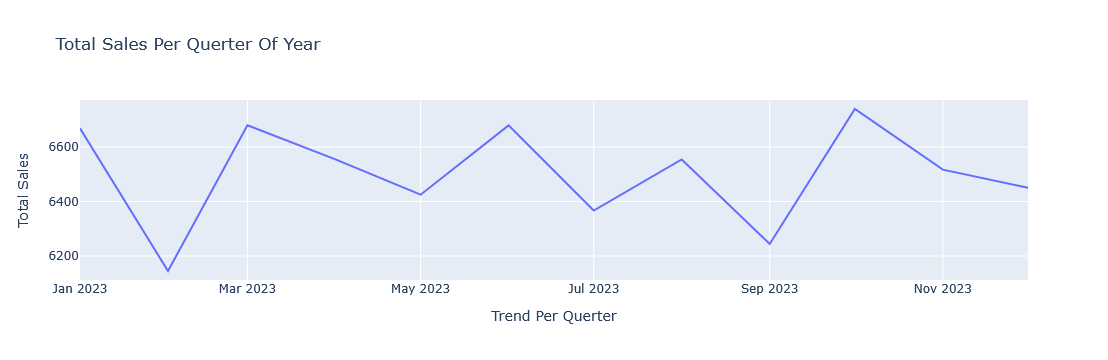

In [39]:
df_temp = df_copy.groupby(df_copy['Transaction Date'].dt.to_period('M'))['Total Spent'].sum().reset_index(name = 'Total_Spent')
df_temp['Transaction Date'] = df_temp['Transaction Date'].astype(str)
line_chart = px.line(df_temp, x = 'Transaction Date', y = 'Total_Spent', title = 'Total Sales Per Querter Of Year')
line_chart.update_xaxes(title_text = 'Trend Per Querter')
line_chart.update_yaxes(title_text = 'Total Sales')
line_chart.show()

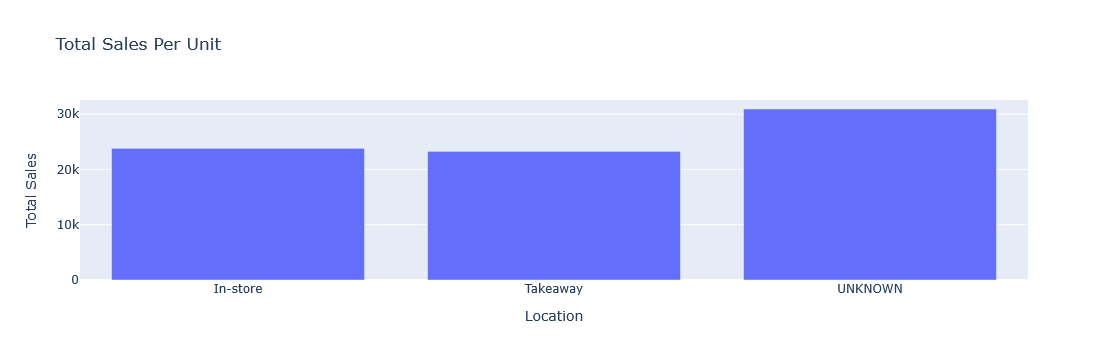

In [41]:
bar_chart2 = px.bar(df_copy.groupby('Location')['Total Spent'].sum().reset_index(name = 'Total Sales Per Location'),
                    x = 'Location', y = 'Total Sales Per Location', title = 'Total Sales Per Unit')
bar_chart2.update_xaxes(title_text = 'Location')
bar_chart2.update_yaxes(title_text = 'Total Sales')
bar_chart2.show()

In [26]:
df_copy.to_csv('Cleaned_Dataset.csv', index = False)


transaction Sucessful
